In [55]:
import cv2
import matplotlib.pyplot as plt

In [56]:
image = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/coins.jpg")

array([[[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [  0, 255,   0],
        [  0, 255,   0]],

       ...,

       [[  0, 255,   0],
        [  0, 255,   0],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]],

       [[  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0],
        ...,
        [  0, 255,   0],
        [  0, 255,   0],
        [  0, 255,   0]]], dtype=uint8)
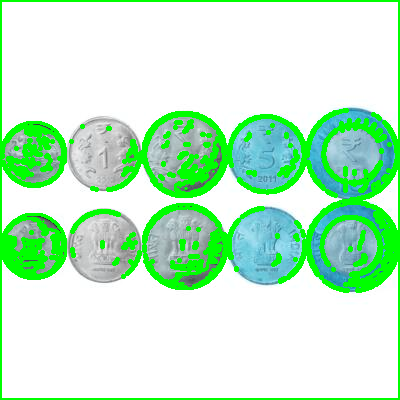

In [57]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(
    gray,
    127,
    255,
    cv2.THRESH_BINARY
)

contours, hierarchy = cv2.findContours(
    binary,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

output = image.copy()

cv2.drawContours(
    output,
    contours,
    -1,
    (0,255,0),
    2
)

In [58]:
print(f"I found {len(contours)} coins")

I found 674 coins


In [59]:
# Loop through the list of contours
for contour in contours:
    # Calculate the area for the current contour item
    area = cv2.contourArea(contour)

    # Example filter: Only print coins larger than a certain size
    if area > 100:
      print(f"Coin detected with area: {area}")


Coin detected with area: 159201.0
Coin detected with area: 316.5
Coin detected with area: 217.5
Coin detected with area: 168.5
Coin detected with area: 913.0
Coin detected with area: 129.0
Coin detected with area: 435.5
Coin detected with area: 296.0
Coin detected with area: 272.5
Coin detected with area: 108.0
Coin detected with area: 115.0
Coin detected with area: 690.5
Coin detected with area: 194.0
Coin detected with area: 312.5
Coin detected with area: 311.5


In [60]:
# Loop through the list of contours
for contour in contours:
    # Calculate the area for the current contour item
    perimeter = cv2.arcLength(contour, True)

    # Example filter: Only print coins larger than a certain size
    if perimeter > 100:
      print(f"Coin detected with perimeter: {perimeter}")


Coin detected with perimeter: 1596.0
Coin detected with perimeter: 196.26702570915222
Coin detected with perimeter: 185.92387998104095
Coin detected with perimeter: 132.46803617477417
Coin detected with perimeter: 398.81832206249237
Coin detected with perimeter: 105.5979790687561
Coin detected with perimeter: 214.8944422006607
Coin detected with perimeter: 207.13708245754242
Coin detected with perimeter: 210.06601512432098
Coin detected with perimeter: 103.5979790687561
Coin detected with perimeter: 240.00713992118835
Coin detected with perimeter: 176.8528118133545
Coin detected with perimeter: 204.06601452827454
Coin detected with perimeter: 234.0660150051117


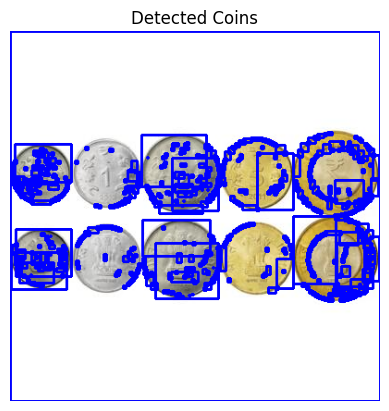

In [61]:
import matplotlib.pyplot as plt

# 1. Make a clean copy of your image to draw on
output = image.copy()

# 2. Run the loop to draw all rectangles in memory
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(
        output,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

# 3. ADD THIS CODE BELOW THE LOOP TO FINALLY GENERATE THE VISUAL OUTPUT
# (Make sure these lines are NOT indented)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Coins")
plt.axis('off')
plt.show()
